# Import Required Libraries

Import các thư viện cần thiết bao gồm pandas, numpy, lightgbm, sklearn.metrics, và matplotlib.

In [47]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import optuna

# Set style for plots
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

# Load and Preprocess Data

Load tập dữ liệu đã xử lý, đảm bảo sắp xếp theo thời gian, xử lý giá trị thiếu trong các biến lag, và chuẩn bị input features và target.

In [48]:
# Load processed data
DATA_PATH = Path('Data') / 'processedData.csv'
df = pd.read_csv(DATA_PATH, parse_dates=['time'])

# Ensure data is sorted by time
df = df.sort_values('time').reset_index(drop=True)

# Define features and target
features = [
    'lat', 'lon', 'abs_lat', 'month_sin', 'month_cos', 'time_index',
    'precip_prev_1m_mean', 'precip_prev_3m_mean', 'precip_prev_12m_mean',
    'precip_monthly_climate', 'quality_flag', 'num_obs_fraction', 'num_obs_rate'
]
target = 'precipitation'

# Handle any remaining missing values in lag features (though they should be filled in preprocessing)
df[features] = df[features].fillna(df[features].median())

# Prepare X and y
X = df[features]
y = df[target]

print(f'Dataset shape: {df.shape}')
print(f'Features: {features}')
print(f'Target: {target}')
print(f'Date range: {df["time"].min()} to {df["time"].max()}')

Dataset shape: (677376, 25)
Features: ['lat', 'lon', 'abs_lat', 'month_sin', 'month_cos', 'time_index', 'precip_prev_1m_mean', 'precip_prev_3m_mean', 'precip_prev_12m_mean', 'precip_monthly_climate', 'quality_flag', 'num_obs_fraction', 'num_obs_rate']
Target: precipitation
Date range: 2005-01-01 00:00:00 to 2020-12-01 00:00:00


# Time-Based Data Split

Chia dữ liệu thành train (2005-2014), validation (2015-2018), và test (2019-2020) mà không shuffle để tránh leakage theo thời gian.

In [49]:
# Time-based split
train_mask = df['year'] <= 2014
val_mask = (df['year'] >= 2015) & (df['year'] <= 2018)
test_mask = df['year'] >= 2019

X_train = X[train_mask]
y_train = y[train_mask]
X_val = X[val_mask]
y_val = y[val_mask]
X_test = X[test_mask]
y_test = y[test_mask]

print(f'Train set: {X_train.shape[0]} samples ({df[train_mask]["year"].min()}-{df[train_mask]["year"].max()})')
print(f'Validation set: {X_val.shape[0]} samples ({df[val_mask]["year"].min()}-{df[val_mask]["year"].max()})')
print(f'Test set: {X_test.shape[0]} samples ({df[test_mask]["year"].min()}-{df[test_mask]["year"].max()})')

Train set: 423360 samples (2005-2014)
Validation set: 169344 samples (2015-2018)
Test set: 84672 samples (2019-2020)


# Configure LightGBM Model

Thiết lập LightGBM Regressor với các siêu tham số được chỉ định: n_estimators=2000, learning_rate=0.03, num_leaves=64, subsample=0.8, colsample_bytree=0.8, random_state=42.

In [50]:
# Initialize LightGBM regressor with tuned hyperparameters
model = lgb.LGBMRegressor(
    n_estimators=8000,
    learning_rate=0.01,

    num_leaves=31,
    max_depth=6,
    min_data_in_leaf=100,

    subsample=0.75,
    colsample_bytree=0.75,

    reg_alpha=0.3,
    reg_lambda=1.0,

    random_state=42
)

# Optimize Hyperparameters with Optuna

Sử dụng Optuna để tối ưu hóa hyperparameters cho LightGBM Regressor dựa trên validation set.

In [51]:
# Define objective function for Optuna
def objective(trial):
    # Suggest hyperparameters
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 2000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),
        'random_state': 42,
        'verbosity': -1
    }

    # Create model with suggested params
    model = lgb.LGBMRegressor(**params)

    # Train on train set
    model.fit(X_train, y_train)

    # Predict on validation set
    y_val_pred = model.predict(X_val)

    # Calculate MAE (primary metric)
    mae = mean_absolute_error(y_val, y_val_pred)

    return mae

# Run Optuna study
study = optuna.create_study(direction='minimize')  # Minimize MAE
study.optimize(objective, n_trials=50)  # Adjust n_trials as needed

# Get best parameters
best_params = study.best_params
best_params['random_state'] = 42
best_params['verbosity'] = 1

print('Best hyperparameters found:')
for param, value in best_params.items():
    print(f'{param}: {value}')
print(f'Best MAE: {study.best_value:.4f}')

# Update model with best parameters
model = lgb.LGBMRegressor(**best_params)

[I 2026-04-14 01:00:48,444] A new study created in memory with name: no-name-99bb5c37-c1e9-4fe5-a07e-4283336d2495
[I 2026-04-14 01:00:50,407] Trial 0 finished with value: 2.127114824374391 and parameters: {'n_estimators': 227, 'learning_rate': 0.0329839431919991, 'num_leaves': 24, 'max_depth': 7, 'subsample': 0.9856114851111308, 'colsample_bytree': 0.7316269409818135, 'min_child_samples': 34, 'reg_alpha': 0.038958603060332386, 'reg_lambda': 0.12527926738955497}. Best is trial 0 with value: 2.127114824374391.
[I 2026-04-14 01:00:57,120] Trial 1 finished with value: 2.506179134164294 and parameters: {'n_estimators': 537, 'learning_rate': 0.08123229320713693, 'num_leaves': 76, 'max_depth': 6, 'subsample': 0.7430538085140277, 'colsample_bytree': 0.8745445982928371, 'min_child_samples': 93, 'reg_alpha': 0.8470863085016601, 'reg_lambda': 0.5013080903439959}. Best is trial 0 with value: 2.127114824374391.
[I 2026-04-14 01:01:07,384] Trial 2 finished with value: 2.2384232387663507 and paramete

Best hyperparameters found:
n_estimators: 324
learning_rate: 0.02658050348828184
num_leaves: 37
max_depth: 5
subsample: 0.8874614541098009
colsample_bytree: 0.7540128959453328
min_child_samples: 16
reg_alpha: 0.1687767305378253
reg_lambda: 0.0015442595197137712
random_state: 42
verbosity: 1
Best MAE: 2.0900


# Train the Model

Train mô hình LightGBM trên tập train sử dụng tập validation để dừng sớm nếu cần.

In [52]:
# Train the model
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    eval_names=['train', 'validation'],
    eval_metric='mae',
    callbacks=[
        lgb.early_stopping(stopping_rounds=100),
        lgb.log_evaluation(period=50)
    ]
)

print('Model training completed.')

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010876 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1784
[LightGBM] [Info] Number of data points in the train set: 423360, number of used features: 12
[LightGBM] [Info] Start training from score 7.561899
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

# Evaluate on Train, Validation, and Test Sets

Tính toán và báo cáo MAE, RMSE, và R² cho tập train, validation, và test.

In [53]:
# Function to calculate metrics
def calculate_metrics(y_true, y_pred, set_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f'{set_name} Metrics:')
    print(f'  MAE: {mae:.4f}')
    print(f'  RMSE: {rmse:.4f}')
    print(f'  R²: {r2:.4f}')
    print()
    return mae, rmse, r2

# Predictions
y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)
y_test_pred = model.predict(X_test)

# Calculate metrics
train_mae, train_rmse, train_r2 = calculate_metrics(y_train, y_train_pred, 'Train')
val_mae, val_rmse, val_r2 = calculate_metrics(y_val, y_val_pred, 'Validation')
test_mae, test_rmse, test_r2 = calculate_metrics(y_test, y_test_pred, 'Test')

Train Metrics:
  MAE: 2.0515
  RMSE: 3.1454
  R²: 0.7243

Validation Metrics:
  MAE: 2.0947
  RMSE: 3.1755
  R²: 0.6939

Test Metrics:
  MAE: 2.1121
  RMSE: 3.2075
  R²: 0.6923



# Analyze Errors by Season

Nhóm dự đoán theo tháng hoặc mùa và tính toán các metric lỗi để phân tích hiệu suất theo mùa.

In [54]:
# Analyze errors by season on test set
test_df = df[test_mask].copy()
test_df['y_true'] = y_test
test_df['y_pred'] = y_test_pred
test_df['error'] = test_df['y_true'] - test_df['y_pred']
test_df['abs_error'] = np.abs(test_df['error'])

# Group by season
seasonal_errors = test_df.groupby('season').agg({
    'abs_error': 'mean',
    'error': ['mean', 'std'],
    'y_true': 'count'
}).round(4)

print('Seasonal Error Analysis (Test Set):')
print(seasonal_errors)
print()

# Group by month
monthly_errors = test_df.groupby('month').agg({
    'abs_error': 'mean',
    'error': ['mean', 'std'],
    'y_true': 'count'
}).round(4)

print('Monthly Error Analysis (Test Set):')
print(monthly_errors)

Seasonal Error Analysis (Test Set):
       abs_error   error         y_true
            mean    mean     std  count
season                                 
DJF       2.0382 -0.9582  2.8522  21168
JJA       2.1743 -0.4666  3.1305  21168
MAM       1.5560 -0.1465  2.2865  21168
SON       2.6799 -0.2554  4.0949  21168

Monthly Error Analysis (Test Set):
      abs_error   error         y_true
           mean    mean     std  count
month                                 
1        1.8391 -0.9584  2.5088   7056
2        1.7840 -1.1661  2.3815   7056
3        1.2326 -0.0773  1.8427   7056
4        1.3257 -0.1214  1.8917   7056
5        2.1098 -0.2408  2.9492   7056
6        1.9774 -0.3233  2.6927   7056
7        2.2912 -1.2086  2.8237   7056
8        2.2541  0.1319  3.6400   7056
9        2.8288 -0.7764  4.1413   7056
10       2.7583  0.3227  4.3145   7056
11       2.4527 -0.3127  3.7329   7056
12       2.4916 -0.7500  3.5150   7056


# Analyze Errors by Geographic Region

Nhóm dự đoán theo bins của lat/lon và tính toán các metric lỗi để phân tích hiệu suất theo vùng địa lý.

In [55]:
# Analyze errors by geographic region on test set
# Create lat/lon bins
test_df['lat_bin'] = pd.cut(test_df['lat'], bins=5, labels=['Very South', 'South', 'Central', 'North', 'Very North'])
test_df['lon_bin'] = pd.cut(test_df['lon'], bins=5, labels=['West', 'Mid-West', 'Central', 'Mid-East', 'East'])

# Group by lat bins
lat_errors = test_df.groupby('lat_bin').agg({
    'abs_error': 'mean',
    'error': ['mean', 'std'],
    'y_true': 'count'
}).round(4)

print('Latitudinal Error Analysis (Test Set):')
print(lat_errors)
print()

# Group by lon bins
lon_errors = test_df.groupby('lon_bin').agg({
    'abs_error': 'mean',
    'error': ['mean', 'std'],
    'y_true': 'count'
}).round(4)

print('Longitudinal Error Analysis (Test Set):')
print(lon_errors)

Latitudinal Error Analysis (Test Set):
           abs_error   error         y_true
                mean    mean     std  count
lat_bin                                    
Very South    2.0799 -0.6946  2.9505  18816
South         2.0468 -0.4004  2.8112  16464
Central       2.2469 -0.5248  3.1486  16464
North         2.3218 -0.4295  3.6970  16464
Very North    1.8697 -0.2002  3.2043  16464

Longitudinal Error Analysis (Test Set):
         abs_error   error         y_true
              mean    mean     std  count
lon_bin                                  
West        2.1501 -0.6307  3.1706  17280
Mid-West    1.7841 -0.3690  2.6899  17280
Central     1.9863 -0.3144  3.1640  15552
Mid-East    2.3496 -0.3626  3.5895  17280
East        2.2778 -0.5925  3.1822  17280


C:\Users\Hello\AppData\Local\Temp\ipykernel_14596\1108317424.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  lat_errors = test_df.groupby('lat_bin').agg({
C:\Users\Hello\AppData\Local\Temp\ipykernel_14596\1108317424.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  lon_errors = test_df.groupby('lon_bin').agg({


# Analyze Errors by Rainfall Level

Phân loại dự đoán thành các mức không mưa, mưa nhẹ, mưa lớn và tính toán các metric lỗi.

In [56]:
# Analyze errors by rainfall level on test set
# Define rainfall categories based on actual values
def categorize_rainfall(precip):
    if precip == 0:
        return 'No Rain'
    elif precip < 5:
        return 'Light Rain'
    elif precip < 25:
        return 'Moderate Rain'
    else:
        return 'Heavy Rain'

test_df['rain_category'] = test_df['y_true'].apply(categorize_rainfall)

# Group by rainfall category
rainfall_errors = test_df.groupby('rain_category').agg({
    'abs_error': 'mean',
    'error': ['mean', 'std'],
    'y_true': ['count', 'mean']
}).round(4)

print('Rainfall Level Error Analysis (Test Set):')
print(rainfall_errors)

Rainfall Level Error Analysis (Test Set):
              abs_error    error         y_true         
                   mean     mean     std  count     mean
rain_category                                           
Heavy Rain      10.4962  10.3425  7.1824    836  29.4648
Light Rain       1.8917  -1.7575  2.2032  36130   1.8462
Moderate Rain    2.1786   0.3760  3.0991  46150  10.3797
No Rain          0.7532  -0.7532  0.8021   1556   0.0000


# Plot Results and Parameters

Tạo biểu đồ cho các tham số mô hình, dự đoán so với thực tế, và phân phối lỗi sau khi train, validate, và test.

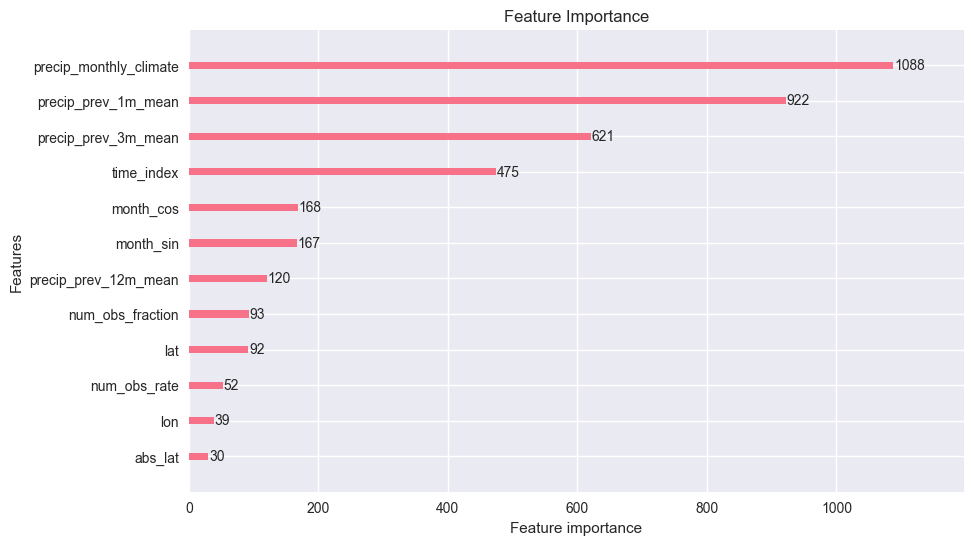

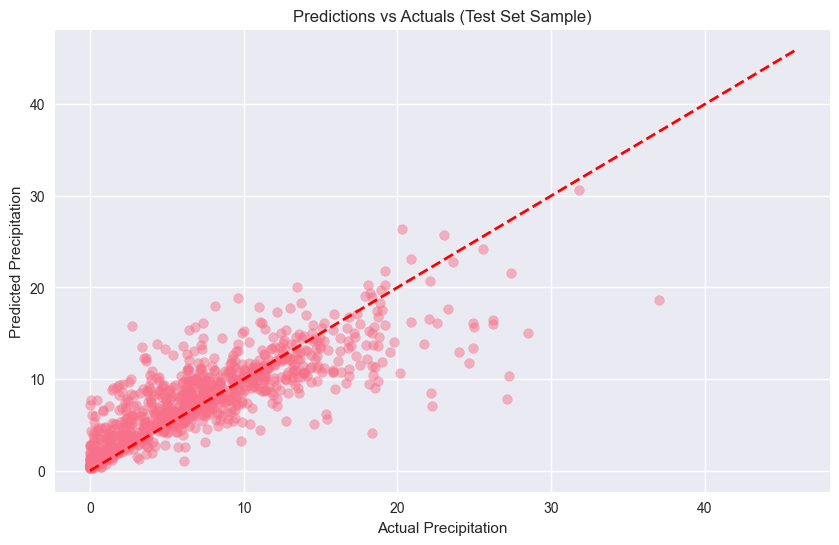

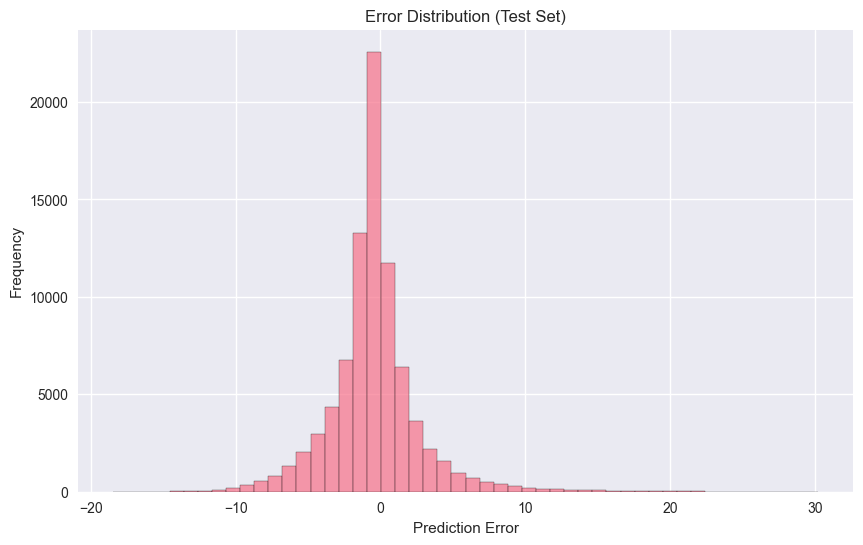

Final Model Parameters:
n_estimators: 324
learning_rate: 0.02658050348828184
num_leaves: 37
subsample: 0.8874614541098009
colsample_bytree: 0.7540128959453328


In [57]:
# Plot feature importance
lgb.plot_importance(model, figsize=(10, 6), max_num_features=15)
plt.title('Feature Importance')
plt.show()

# Plot predictions vs actuals for test set (sample)
sample_size = 1000
sample_indices = np.random.choice(len(y_test), sample_size, replace=False)

plt.figure(figsize=(10, 6))
plt.scatter(y_test.iloc[sample_indices], y_test_pred[sample_indices], alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Actual Precipitation')
plt.ylabel('Predicted Precipitation')
plt.title('Predictions vs Actuals (Test Set Sample)')
plt.grid(True)
plt.show()

# Plot error distribution
plt.figure(figsize=(10, 6))
plt.hist(test_df['error'], bins=50, alpha=0.7, edgecolor='black')
plt.xlabel('Prediction Error')
plt.ylabel('Frequency')
plt.title('Error Distribution (Test Set)')
plt.grid(True)
plt.show()

# Print final model parameters
print('Final Model Parameters:')
for param in ['n_estimators', 'learning_rate', 'num_leaves', 'subsample', 'colsample_bytree']:
    print(f'{param}: {model.get_params()[param]}')